In [10]:
import random
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale

# funcao que cria dados falsos de renda/idade agrupados em k clusters, pra N pessoas (igual a da aula)
def createClusteredData(N, k):
    random.seed(10)
    pointsPerCluster = float(N)/k
    X = []
    for i in range (k):
        incomeCentroid = random.uniform(20000.0, 200000.0)
        ageCentroid = random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
    X = np.array(X)
    return X

# gerando 100 pessoas falsas divididas em 5 clusters, igual no notebook da aula
data = createClusteredData(100, 5)

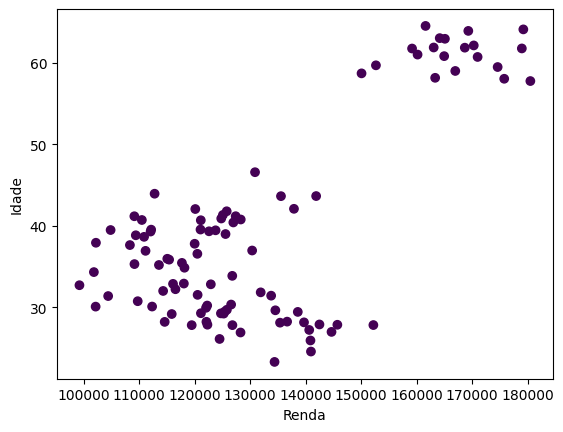

Cluster 1 com inercia = 200.00000000000003


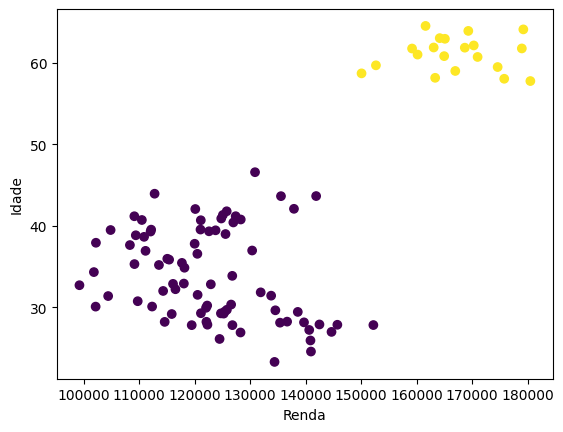

Cluster 2 com inercia = 45.62835584306645


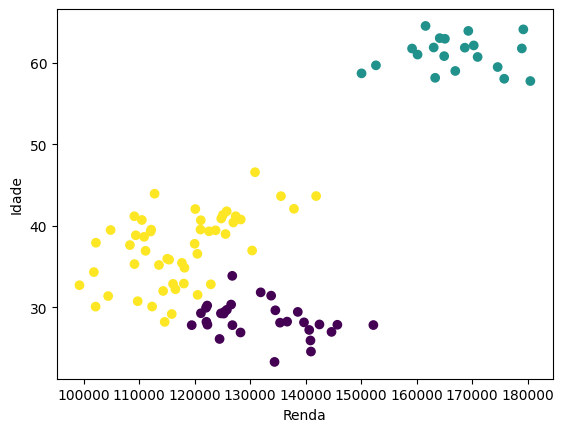

Cluster 3 com inercia = 26.54007751755012


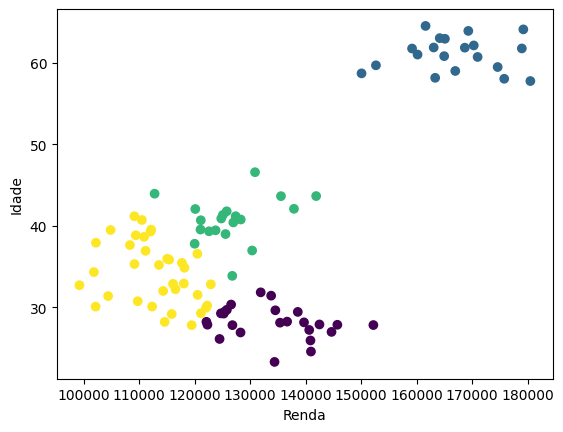

Cluster 4 com inercia = 17.821081255462087


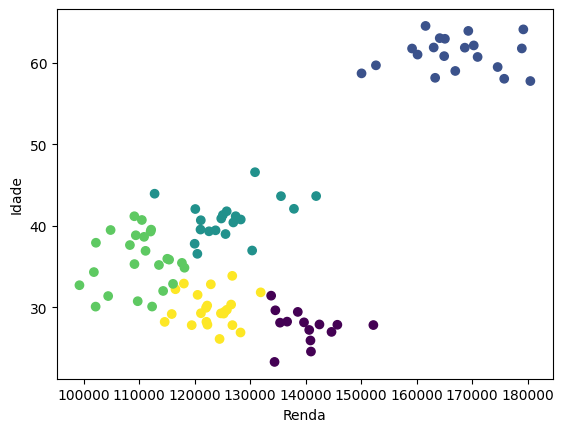

Cluster 5 com inercia = 12.49216407746572


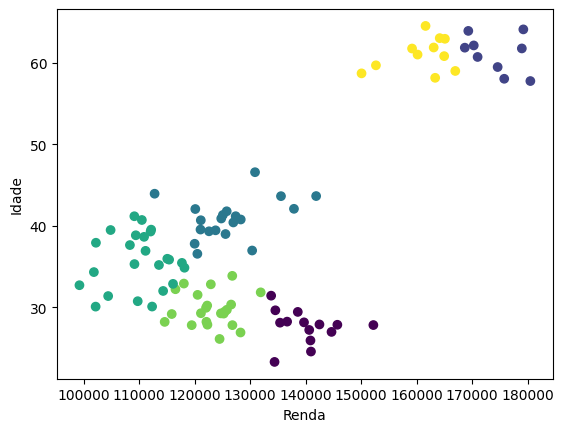

Cluster 6 com inercia = 10.479269583851261


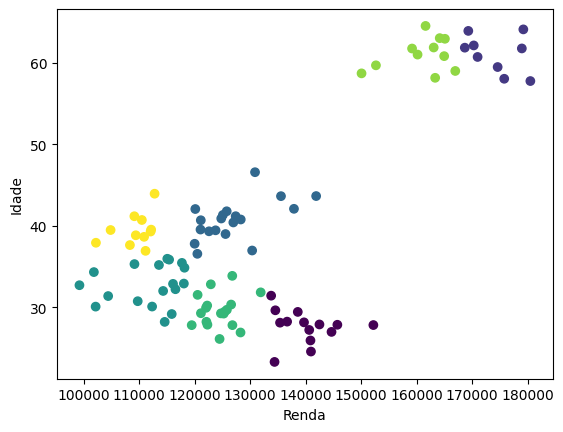

Cluster 7 com inercia = 8.678450895936681


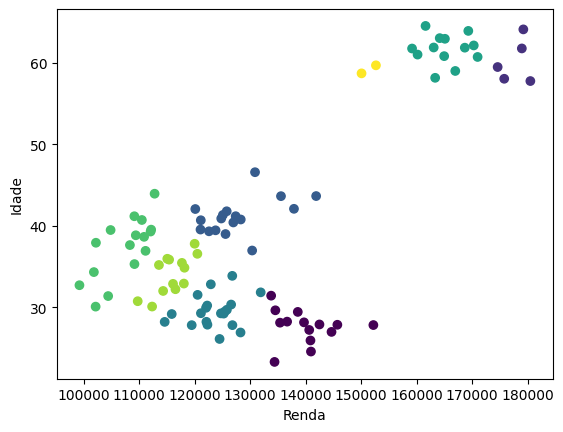

Cluster 8 com inercia = 8.124831693216233


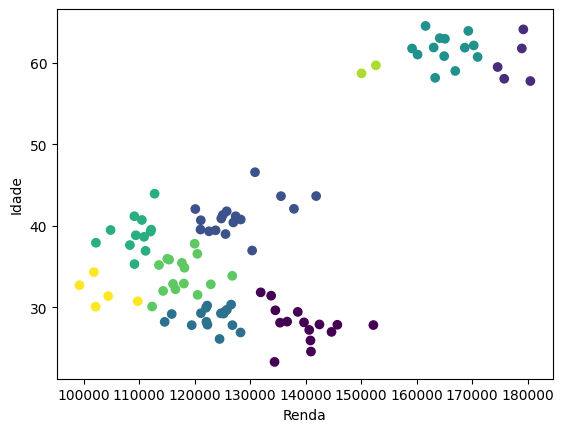

Cluster 9 com inercia = 6.72842505721311


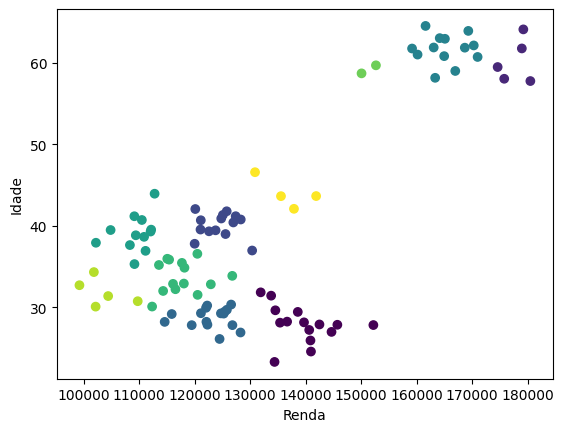

Cluster 10 com inercia = 5.42771645628115


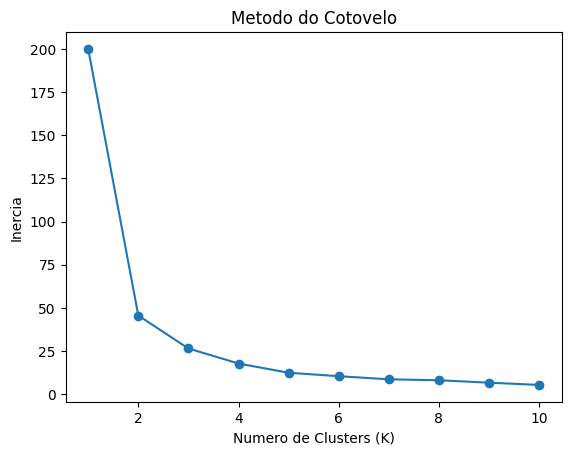

In [30]:
sla = [1,2,3,4,5,6,7,8,9,10]  # valores de k que eu quero testar
inercias = []  # vou guardar a inercia de cada k aqui

for i in sla:
    # treina um kmeans novo pra cada valor de k, usando os mesmos dados escalados
    model = KMeans(n_clusters=i, random_state=10)
    model.fit(scale(data))
    labels = model.labels_
    inercia = model.inertia_
    inercias.append(model.inertia_)
    
    # plota o cluster resultante desse k, so pra eu ver visualmente como ficou
    plt.scatter(data[:, 0], data[:, 1], c=labels)
    plt.xlabel("Renda")
    plt.ylabel("Idade")
    plt.show()
    print(f'Cluster {i} com inercia = {inercia}')
    
# depois do loop, plota a inercia de cada k pra achar o melhor cluster 
plt.plot(sla, inercias, marker='o')
plt.xlabel("Numero de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Metodo do Cotovelo")
plt.show() #no final vou ter um grafico de cada cluster indo de 1 a 10 e encontrando o melhor deles pelo metodo do cotovelo